In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import custom parser
from survey_parser import load_config, parse_results

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [2]:
# --- 1. Load and Parse Data ---
survey_config = load_config('config.json')
parsed_results = parse_results(survey_config, 'results.csv')
df = pd.read_csv('results.csv')

print(f"Loaded {len(df)} survey responses.")

Loaded 152 survey responses.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ==========================================
# 1. POPULATION SPLITTING
# ==========================================
# CONFIGURATION: Set to False to swap missing answers into the 'Incorrect' population
TREAT_MISSING_AS_CORRECT = True

topsis_col = 'q1_topsis_pos'
ip_col = 'q1_IP_pos'

# Calculate absolute difference in rank between the duplicate CFEs
df['q1_dupe_dist'] = (df[topsis_col] - df[ip_col]).abs()

if TREAT_MISSING_AS_CORRECT:
    # Threshold <= 1 (includes exact matches and adjacent rankings) OR missing answers
    is_correct = df['q1_dupe_dist'].le(1) | df['q1_dupe_dist'].isna()
else:
    # Threshold <= 1 strictly
    is_correct = df['q1_dupe_dist'].le(1)

# Assign Population Labels
df['Population'] = np.where(is_correct, 'Correct (<=1 or NaN)', 'Incorrect (>1)')

print("Population sizes:")
print(df['Population'].value_counts())

Population sizes:
Population
Correct (<=1 or NaN)    93
Incorrect (>1)          59
Name: count, dtype: int64


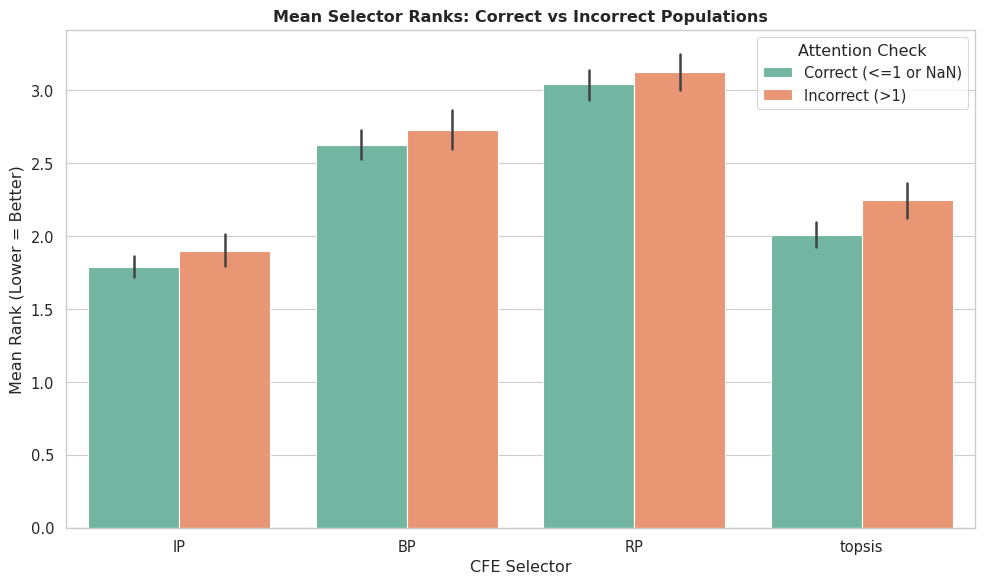

--- Mann-Whitney U Test (Correct vs Incorrect) ---
IP      : U-stat=58000.5, p-value=2.1325e-01 
BP      : U-stat=57899.5, p-value=2.1505e-01 
RP      : U-stat=57653.0, p-value=1.6037e-01 
topsis  : U-stat=53616.5, p-value=3.4564e-03 *


In [4]:
# ==========================================
# 2. RANKING PREFERENCES: CORRECT VS INCORRECT
# ==========================================
selectors = ['IP', 'BP', 'RP', 'topsis']
ranking_qs = ['q1', 'q5', 'q7', 'q13', 'q15'] 

# Flatten the ranks to allow for Seaborn plotting and SciPy testing
comp_rows = []
for idx, row in df.iterrows():
    pop = row['Population']
    for q in ranking_qs:
        for s in selectors:
            col = f"{q}_{s}_pos"
            if col in df.columns and pd.notna(row[col]):
                comp_rows.append({
                    'Subject_ID': idx,
                    'Population': pop,
                    'Selector': s,
                    'Rank': row[col]
                })

df_comp = pd.DataFrame(comp_rows)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_comp, 
    x='Selector', 
    y='Rank', 
    hue='Population', 
    errorbar=('ci', 95), 
    palette='Set2'
)
plt.title('Mean Selector Ranks: Correct vs Incorrect Populations', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('CFE Selector')
plt.legend(title='Attention Check')
plt.tight_layout()
plt.show()

# Statistical Significance (Mann-Whitney U Test for Independent Samples)
print("--- Mann-Whitney U Test (Correct vs Incorrect) ---")
for s in selectors:
    ranks_correct = df_comp[(df_comp['Selector'] == s) & (df_comp['Population'] == 'Correct (<=1 or NaN)')]['Rank']
    ranks_incorrect = df_comp[(df_comp['Selector'] == s) & (df_comp['Population'] == 'Incorrect (>1)')]['Rank']
    
    stat, p_val = stats.mannwhitneyu(ranks_correct, ranks_incorrect, alternative='two-sided', nan_policy='omit')
    
    sig = "*" if p_val < 0.05 else ""
    print(f"{s:8}: U-stat={stat:6.1f}, p-value={p_val:.4e} {sig}")

--- Comparative Analysis by Population ---


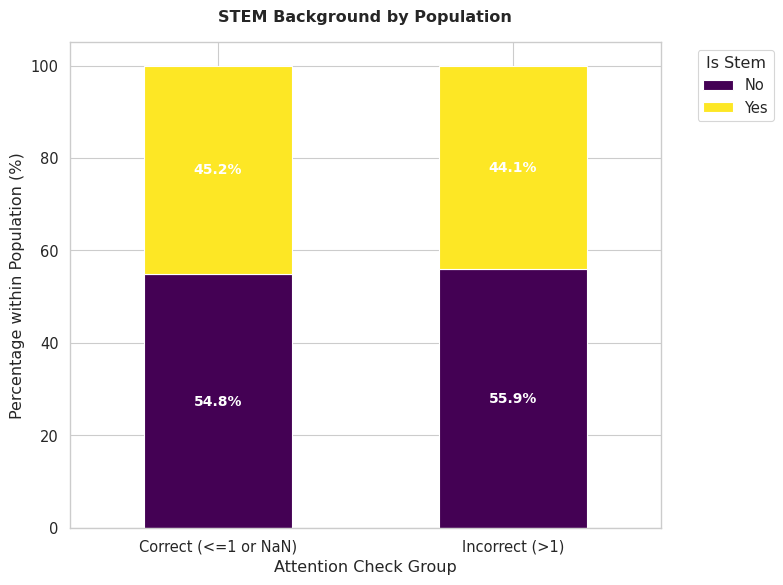

Chi-Square p-value (is_stem split by Population): 1.0000



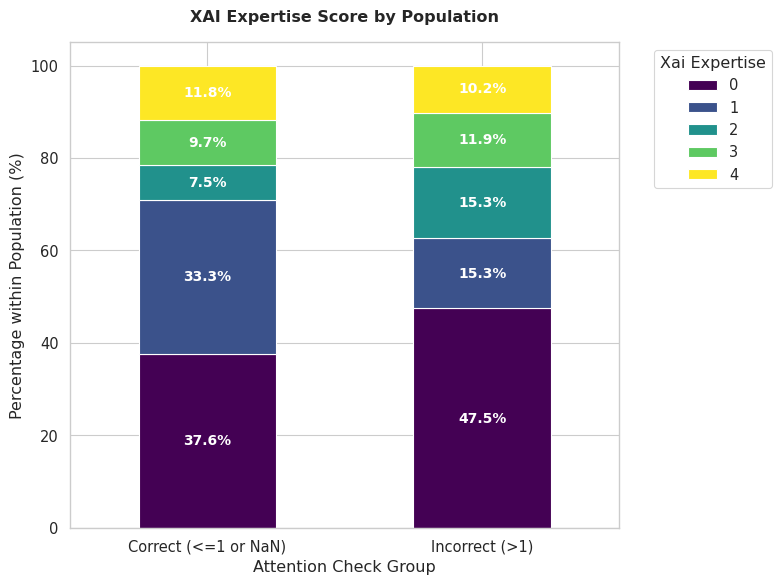

Chi-Square p-value (xai_expertise split by Population): 0.1063



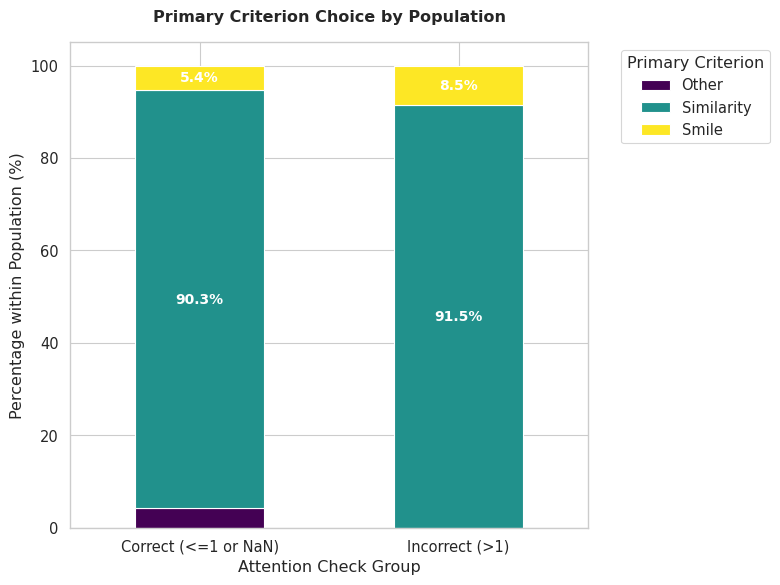

Chi-Square p-value (primary_criterion split by Population): 0.2154



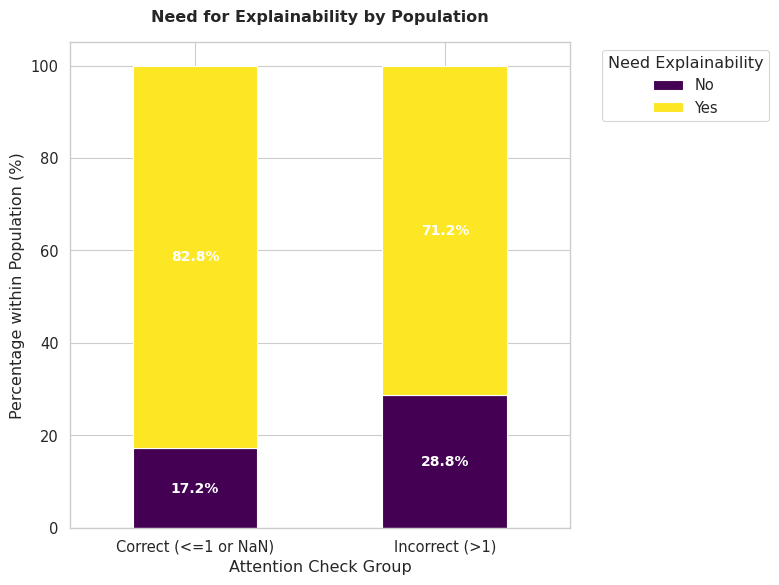

Chi-Square p-value (need_explainability split by Population): 0.1362



In [5]:
# ==========================================
# 3. DEMOGRAPHICS & CRITERIA COMPARISON
# ==========================================
# Helper function to plot normalized 100% stacked bars and run Chi-Square
def plot_pop_comparison(df_source, col_hue, title):
    temp_df = df_source.dropna(subset=['Population', col_hue]).copy()
    crosstab = pd.crosstab(temp_df['Population'], temp_df[col_hue], normalize='index') * 100
    
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis', edgecolor='white')
    plt.title(title, fontweight='bold', pad=15)
    plt.ylabel('Percentage within Population (%)')
    plt.xlabel('Attention Check Group')
    plt.legend(title=col_hue.replace('_', ' ').title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    
    for c in ax.containers:
        labels = [f'{w:.1f}%' if w > 5 else '' for w in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

    # Chi-Square Test to check if the distributions differ significantly
    contingency = pd.crosstab(temp_df['Population'], temp_df[col_hue])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    print(f"Chi-Square p-value ({col_hue} split by Population): {p:.4f}\n")

# Re-create engineered features if needed for this scope
stem_fields = ['Engineering and Technology', 'Exact and Natural Sciences', 'Medical and Health Sciences', 'Agricultural Sciences']
df['is_stem'] = df['education_field'].apply(lambda x: 'Yes' if x in stem_fields else 'No')

knowledge_cols = ['familiar_ml', 'familiar_metrics', 'experience_explainability', 'experience_counterfactuals']
df['xai_expertise'] = df[knowledge_cols].apply(lambda x: sum(x == 'Yes'), axis=1)

df['primary_criterion'] = df['q_most_important_criterion'].apply(
    lambda x: 'Similarity' if pd.notna(x) and 'similarity' in str(x) 
    else ('Smile' if pd.notna(x) and 'smile' in str(x) else 'Other')
)

print("--- Comparative Analysis by Population ---")
plot_pop_comparison(df, 'is_stem', 'STEM Background by Population')
plot_pop_comparison(df, 'xai_expertise', 'XAI Expertise Score by Population')
plot_pop_comparison(df, 'primary_criterion', 'Primary Criterion Choice by Population')
plot_pop_comparison(df, 'need_explainability', 'Need for Explainability by Population')